# Federal R&D Budget: Tidy Data Analysis

**Course:** SP26-MDSC-20009-01  
**Assignment:** Portfolio Update 2  
**Dataset:** Federal R&D Budgets (1976–2017), adapted from [TidyTuesday](https://github.com/rfordatascience/tidytuesday/tree/main/data/2019/2019-02-12)

---

## Project Overview

In this notebook, we apply **tidy data principles** as described by Hadley Wickham to transform a wide-format dataset of U.S. Federal R&D spending into a clean, analysis-ready format. According to the [Tidy Data paper](https://vita.had.co.nz/papers/tidy-data.pdf), a tidy dataset satisfies three rules:

1. Each **variable** forms its own column.
2. Each **observation** forms its own row.
3. Each **type of observational unit** forms its own table.

The raw dataset violates these rules — year and GDP information are encoded together in column headers, and each row spans multiple years. We will fix this using `pandas` `melt()`, `str.split()`, and `str.replace()`, then perform exploratory data analysis and visualizations.

---

## Table of Contents
1. Import Libraries
2. Load & Inspect Raw Data
3. Tidy the Data (Melt + Split + Clean)
4. Verify Tidy Structure
5. Exploratory Data Analysis (Pivot Table / Aggregations)
6. Visualization 1: Total R&D Spending by Department Over Time
7. Visualization 2: R&D Spending as a Percentage of GDP by Department

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns



## Section 2: Load & Inspect Raw Data

Before we can apply tidy data principles, we need to understand the **raw structure** of the dataset.

The `fed_rd_year&gdp.csv` file contains U.S. Federal R&D budget allocations by department from 1976–2017. In its raw form, this dataset is **untidy** because:

- The column headers encode **two variables at once**: the year and the GDP value (e.g., `1976_gdp1790000000000.0`)
- Each row represents a department, but each cell holds a spending value for a specific year — meaning **multiple observations are stored in a single row**

This violates Wickham's tidy data principles. We'll load the data and inspect its shape and columns to confirm the problem before fixing it.

In [5]:
# Section 2: Load & Inspect Raw Data

# Load CSV directly from the data folder
df_raw = pd.read_csv("data/fed_rd_year&gdp.csv")

print( "Shape ")
print(f"Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")

print("\nColumn Names (first 5)")
print(df_raw.columns[:5].tolist())

print("\n First 3 Rows (first 5 columns)")
df_raw.iloc[:3, :5]

Shape 
Rows: 14, Columns: 43

Column Names (first 5)
['department', '1976_gdp1790000000000.0', '1977_gdp2028000000000.0', '1978_gdp2278000000000.0', '1979_gdp2570000000000.0']

 First 3 Rows (first 5 columns)


,department,1976_gdp1790000000000.0,1977_gdp2028000000000.0,1978_gdp2278000000000.0,1979_gdp2570000000000.0
0,DHS,NaN,NaN,NaN,NaN
1,DOC,8.190000e+08,8.370000e+08,8.710000e+08,9.520000e+08
2,DOD,3.569600e+10,3.796700e+10,3.702200e+10,3.717400e+10


## Section 3: Tidy the Data

### Why is this data untidy?

The raw dataset is in **wide format** — each year occupies its own column, and the column names encode two variables simultaneously: the **year** and the **U.S. GDP** for that year (e.g., `1976_gdp1790000000000.0`). This violates tidy data principles because:

- A single column header carries two pieces of information (year + GDP), not just one variable
- Multiple observations per department are spread across many columns instead of having one row per observation

### The Tidying Strategy

We will use the following steps to reshape this into a tidy format:

1. **`pd.melt()`** — Convert from wide to long format. Each year column becomes a row, creating a new column called `year_gdp` containing values like `1976_gdp1790000000000.0`
2. **`str.split('_gdp', expand=True)`** — Split `year_gdp` into two new columns: `year` and `gdp`
3. **`str.replace()`** — Clean up any trailing `.0` in the GDP strings
4. **Type conversion** — Cast `year`, `gdp`, and `rd_budget` to appropriate numeric types
5. **Drop null values** — Remove rows where the department had no budget (e.g., DHS before it existed)

After tidying, the dataset will have **4 columns**: `department`, `year`, `rd_budget`, `gdp` — one variable per column and one observation per row.

In [ ]:
# melt turns the wide table into long format -- each year column becomes a row
# keeping department as the id column, the new column is called year_gdp for now
df_long = df_raw.melt(
    id_vars='department',
    var_name='year_gdp',      # column headers like '1976_gdp1790000000000.0'
    value_name='rd_budget'   # actual R&D spending value
)
print("After melt -- shape:", df_long.shape)
print("Sample year_gdp values:", df_long['year_gdp'].head(3).tolist())

# now I need to split year_gdp into two columns -- year and gdp
# splitting on '_gdp' gives me ['1976', '1790000000000.0'] which is what I want
split_cols = df_long['year_gdp'].str.split('_gdp', expand=True)
df_long['year'] = split_cols[0]
df_long['gdp']  = split_cols[1]
print("\nAfter str.split() -- new columns created: 'year', 'gdp'")
print(df_long[['year_gdp', 'year', 'gdp']].head(3))

# the gdp values have a trailing '.0' which I want to remove before converting to int
df_long['gdp'] = df_long['gdp'].str.replace(r'\.0$', '', regex=True)
print("\nAfter str.replace() -- cleaned GDP column:")
print(df_long['gdp'].head(3).tolist())

# don't need year_gdp anymore since I already split it
df_long = df_long.drop(columns=['year_gdp'])

# converting columns to proper numeric types
df_long['year']      = pd.to_numeric(df_long['year'])
df_long['gdp']       = pd.to_numeric(df_long['gdp'])
df_long['rd_budget'] = pd.to_numeric(df_long['rd_budget'])

# drop rows with no budget value -- DHS didn't exist until 2002 so those are just NaN
df_tidy = df_long.dropna(subset=['rd_budget']).reset_index(drop=True)

print("\n Final Tidy DataFrame ")
print("Shape:", df_tidy.shape)
print("Columns:", df_tidy.columns.tolist())
print("Data types:")
print(df_tidy.dtypes)
df_tidy.head(10)

After melt -- shape: (588, 3)
Sample year_gdp values: ['1976_gdp1790000000000.0', '1976_gdp1790000000000.0', '1976_gdp1790000000000.0']

After str.split() -- new columns created: 'year', 'gdp'
                  year_gdp  year              gdp
0  1976_gdp1790000000000.0  1976  1790000000000.0
1  1976_gdp1790000000000.0  1976  1790000000000.0
2  1976_gdp1790000000000.0  1976  1790000000000.0

After str.replace() -- cleaned GDP column:
['1790000000000', '1790000000000', '1790000000000']

=== Final Tidy DataFrame ===
Shape: (562, 4)
Columns: ['department', 'rd_budget', 'year', 'gdp']
Data types:
department     object
rd_budget     float64
year            int64
gdp             int64
dtype: object


,department,rd_budget,year,gdp
0,DOC,8.190000e+08,1976,1790000000000
1,DOD,3.569600e+10,1976,1790000000000
2,DOE,1.088200e+10,1976,1790000000000
3,DOT,1.142000e+09,1976,1790000000000
4,EPA,9.680000e+08,1976,1790000000000
5,HHS,9.226000e+09,1976,1790000000000
6,Interior,1.152000e+09,1976,1790000000000
7,NASA,1.251300e+10,1976,1790000000000
8,NIH,8.025000e+09,1976,1790000000000
9,NSF,2.372000e+09,1976,1790000000000


## Section 4: Verify Tidy Structure

After transformation, our dataset now satisfies all three tidy data rules:

| Rule | Before (Wide) | After (Tidy) |
|------|--------------|-------------|
| Each variable in its own column | ❌ Year and GDP were combined in one column name | ✅ `year`, `gdp`, `rd_budget`, `department` each in separate columns |
| Each observation in its own row | ❌ 42 years packed into one row per department | ✅ One row per department-year combination |
| Each observational unit in one table | ✅ Already satisfied | ✅ Maintained |

The tidy data format makes it straightforward to filter, group, and aggregate. For example, we can now easily ask: *"What was NASA's R&D budget in 2000?"* with a simple filter — something impossible with the original wide format without first knowing which column corresponded to year 2000.

> **Reference:** Wickham, H. (2014). Tidy Data. *Journal of Statistical Software*, 59(10). https://vita.had.co.nz/papers/tidy-data.pdf

## Section 5: Exploratory Data Analysis — Pivot Table & Aggregations

Now that our data is tidy, we can  run aggregations that would have been complex or impossible on the original wide-format dataset.

### Aggregation Questions We'll Answer:
1. **What is the average annual R&D budget for each department** across all available years?
2. **Which decade had the highest total federal R&D spending?**
3. **What is the total R&D budget per department per decade?** (Pivot table)

Using `groupby()` and `pivot_table()` on the tidy data makes these questions trivial to answer — a key advantage of the tidy format as described in the [Pandas Cheat Sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf).

In [8]:
# now that the data is tidy I can actually run these aggregations easily
# groupby avg rd_budget per department, sorted highest to lowest
avg_budget = (
    df_tidy
    .groupby('department')['rd_budget']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'rd_budget': 'avg_annual_rd_budget'})
)
# converting to billions so the numbers aren't a huge mess
avg_budget['avg_annual_rd_budget_B'] = (avg_budget['avg_annual_rd_budget'] / 1e9).round(2)
print("=== Average Annual R&D Budget by Department (in $Billions) ===")
print(avg_budget[['department', 'avg_annual_rd_budget_B']].to_string(index=False))

# adding a decade column to group years together
df_tidy['decade'] = (df_tidy['year'] // 10 * 10).astype(str) + 's'
decade_totals = (
    df_tidy
    .groupby('decade')['rd_budget']
    .sum()
    .reset_index()
    .rename(columns={'rd_budget': 'total_rd_budget'})
)
decade_totals['total_rd_budget_B'] = (decade_totals['total_rd_budget'] / 1e9).round(1)
print("\n=== Total Federal R&D Spending by Decade (in $Billions) ===")
print(decade_totals[['decade', 'total_rd_budget_B']].to_string(index=False))

# pivot table -- total rd budget broken down by department and decade
pivot = pd.pivot_table(
    df_tidy,
    values='rd_budget',
    index='department',
    columns='decade',
    aggfunc='sum'
)
# dividing by 1e9 so the numbers are in billions and easier to read
pivot_B = (pivot / 1e9).round(1)
print("\n=== Pivot Table: Total R&D Budget ($Billions) by Department and Decade ===")
pivot_B

=== Average Annual R&D Budget by Department (in $Billions) ===
department  avg_annual_rd_budget_B
       DOD                   64.69
       HHS                   22.30
       NIH                   21.12
      NASA                   12.14
       DOE                   11.88
       NSF                    4.04
      USDA                    2.38
     Other                    1.49
       DOC                    1.23
       DHS                    0.99
       DOT                    0.92
  Interior                    0.90
       EPA                    0.75
        VA                    0.73

=== Total Federal R&D Spending by Decade (in $Billions) ===
decade  total_rd_budget_B
 1970s              369.5
 1980s             1104.5
 1990s             1294.1
 2000s             1860.5
 2010s             1459.4

=== Pivot Table: Total R&D Budget ($Billions) by Department and Decade ===


decade,1970s,1980s,1990s,2000s,2010s
department,,,,,
DHS,NaN,NaN,NaN,9.4,6.5
DOC,3.5,7.8,13.3,14.7,12.4
DOD,147.9,580.0,580.1,807.1,601.6
DOE,55.9,120.5,107.8,109.1,105.9
DOT,4.4,7.9,8.9,9.6,7.8
EPA,4.2,6.8,8.4,7.5,4.7
HHS,39.4,110.9,179.4,337.5,269.2
Interior,4.5,8.5,9.4,8.2,7.2
NASA,50.7,91.8,139.2,132.9,95.4


## Section 6: Visualization 1 — R&D Spending by Department Over Time (Line Chart)

### Why this visualization?

A **line chart** is the ideal choice here because we have continuous time-series data. Each department's R&D spending trajectory across 1976–2017 tells a compelling story — we can observe the dramatic DOD surge during the Cold War era, the explosive growth of HHS and NIH funding in the 2000s, and relative budget trends for smaller agencies.

This visualization would have been **impossible to create directly** from the original wide-format data without first tidying it — the tidy format allows us to simply use `hue='department'` to automatically color-code by agency.

> **Note:** Departments with budget values only in recent years (e.g., DHS, which was created in 2002) appear as shorter lines — this is expected and reflects real-world budget history.

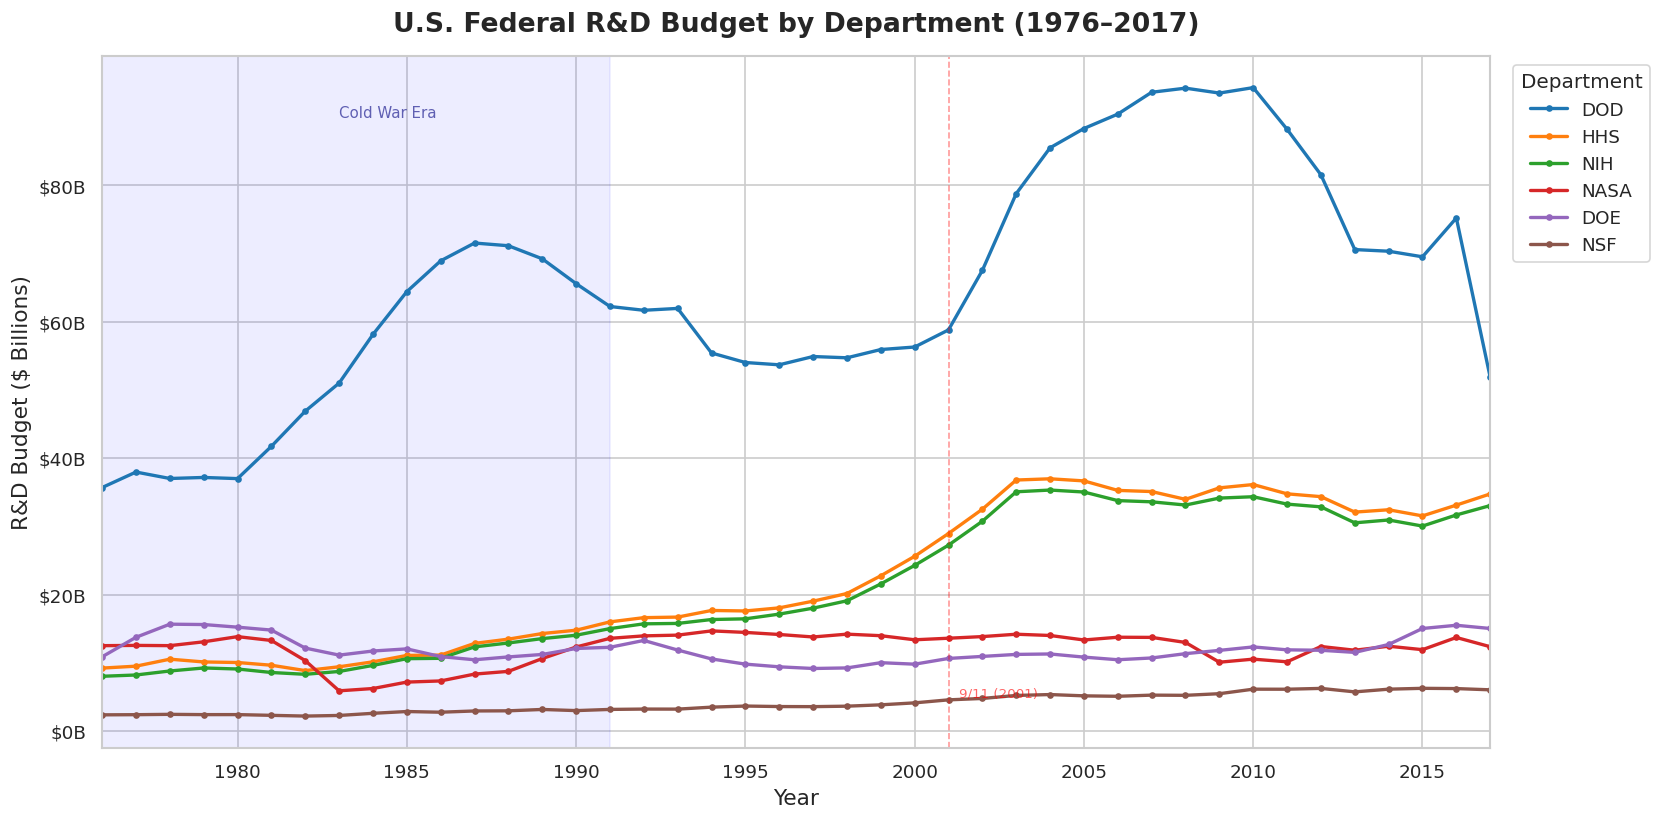

Visualization 1 saved.


In [ ]:
# line chart for R&D spending over time -- picked the top 6 departments so it's not too cluttered
# converting to billions first
df_plot = df_tidy.copy()
df_plot['rd_budget_B'] = df_plot['rd_budget'] / 1e9

# only showing the 6 biggest departments -- 14 lines on one chart would be unreadable
major_depts = ['DOD', 'HHS', 'NIH', 'NASA', 'DOE', 'NSF']
df_major = df_plot[df_plot['department'].isin(major_depts)]

fig, ax = plt.subplots(figsize=(14, 7))

# looping through each dept to plot its line individually
for dept in major_depts:
    dept_data = df_major[df_major['department'] == dept].sort_values('year')
    ax.plot(dept_data['year'], dept_data['rd_budget_B'],
            marker='o', markersize=3, linewidth=2, label=dept)

# chart labels and formatting
ax.set_title('U.S. Federal R&D Budget by Department (1976–2017)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('R&D Budget ($ Billions)', fontsize=13)
ax.legend(title='Department', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11)
ax.set_xlim(1976, 2017)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))

# shading the Cold War era because DOD spending was really high during that period
ax.axvspan(1976, 1991, alpha=0.07, color='blue', label='Cold War Era')
ax.text(1983, 90, 'Cold War Era', fontsize=9, color='navy', alpha=0.6)

# adding a line at 2001 since that's when DHS was created after 9/11
ax.axvline(x=2001, color='red', linestyle='--', alpha=0.4, linewidth=1)
ax.text(2001.3, 5, '9/11 (2001)', fontsize=8, color='red', alpha=0.6)

plt.tight_layout()
plt.savefig('viz1_rd_over_time.png', bbox_inches='tight', dpi=150)
plt.show()
print("Visualization 1 saved.")

## Section 7: Visualization 2 — Average R&D Budget by Department (Horizontal Bar Chart)

### Why this visualization?

A **horizontal bar chart** is ideal for comparing a single aggregate value (average R&D budget) across 14 named categories (departments). It makes ranking easy and labels are clearly readable — unlike a vertical bar chart where long department names would overlap.

This chart complements Visualization 1 by providing a **cross-sectional summary** rather than a time-series view. Together they answer:
- *"How has spending changed over time?"* (Line Chart)
- *"Who receives the most funding on average?"* (Bar Chart)

The fact that we can ask these questions with minimal code is a direct benefit of having tidy data — each row is one observation, making `groupby()` operations straightforward.

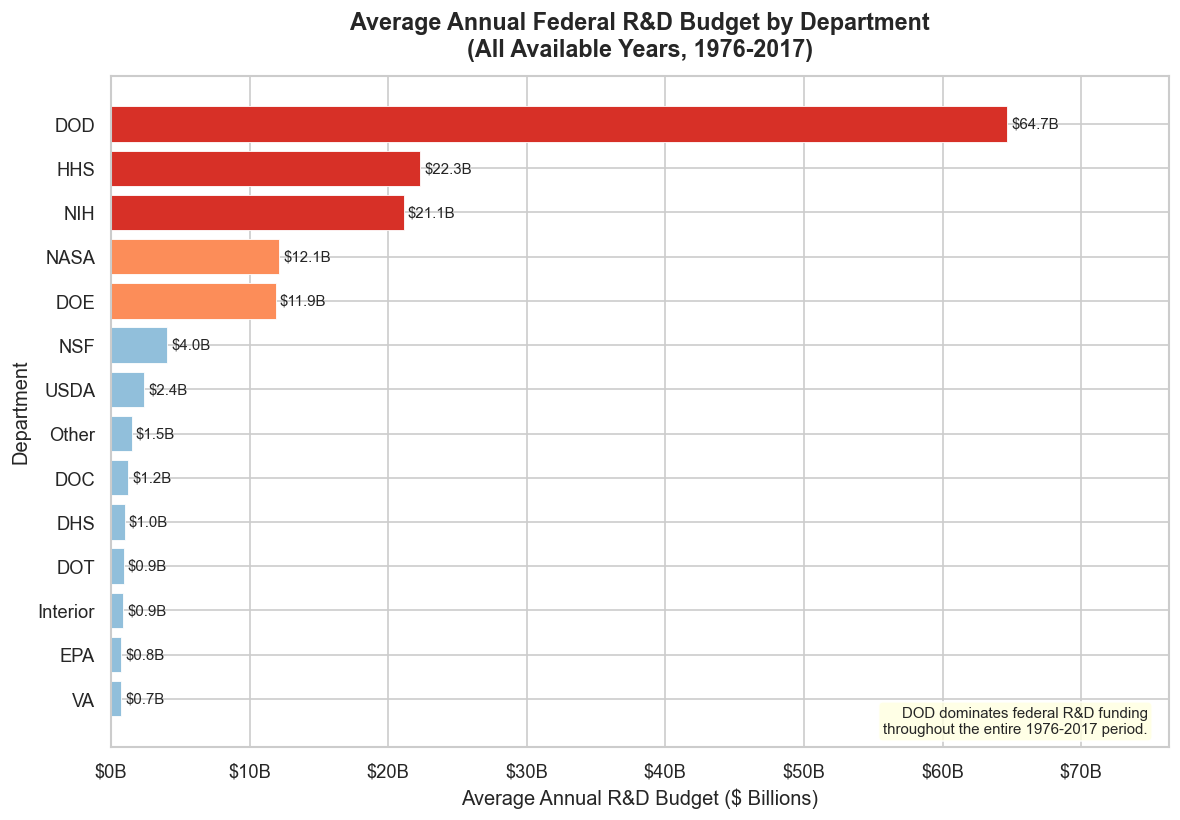

Visualization 2 saved.


In [9]:
# average R&D budget per department across all years -- sorted ascending for horizontal bar
avg_by_dept = (
    df_tidy
    .groupby('department')['rd_budget']
    .mean()
    .reset_index()
    .rename(columns={'rd_budget': 'avg_rd_budget'})
    .sort_values('avg_rd_budget', ascending=True)  # ascending for horizontal bar
)
avg_by_dept['avg_rd_budget_B'] = avg_by_dept['avg_rd_budget'] / 1e9

fig, ax = plt.subplots(figsize=(10, 7))

# color-coding bars by spending level
colors = ['#d73027' if v > 20 else '#fc8d59' if v > 5 else '#91bfdb'
          for v in avg_by_dept['avg_rd_budget_B']]
bars = ax.barh(
    avg_by_dept['department'],
    avg_by_dept['avg_rd_budget_B'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# adding a dollar label at the end of each bar so you can read the exact value
for bar, val in zip(bars, avg_by_dept['avg_rd_budget_B']):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'${val:.1f}B',
        va='center', ha='left', fontsize=9
    )

# chart formatting
ax.set_title('Average Annual Federal R&D Budget by Department\n(All Available Years, 1976-2017)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Average Annual R&D Budget ($ Billions)', fontsize=12)
ax.set_ylabel('Department', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax.set_xlim(0, avg_by_dept['avg_rd_budget_B'].max() * 1.18)

# added a small annotation box noting DOD's dominance -- this was the most interesting finding
ax.text(0.98, 0.02,
        'DOD dominates federal R&D funding\nthroughout the entire 1976-2017 period.',
        transform=ax.transAxes, fontsize=9, ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('viz2_avg_budget_by_dept.png', bbox_inches='tight', dpi=150)
plt.show()
print("Visualization 2 saved.")

## Summary & Conclusions

### What We Accomplished

In this notebook, we successfully applied **tidy data principles** to transform a messy, wide-format dataset into a clean, analysis-ready format. Here is a recap of what was done:

| Step | Action | Tool Used |
|------|--------|-----------|
| 1 | Identified untidy structure (year + GDP encoded in column headers) | `df_raw.head()`, `df_raw.columns` |
| 2 | Melted wide format to long format | `pd.melt()` |
| 3 | Extracted `year` and `gdp` from a single column | `str.split('_gdp', expand=True)` |
| 4 | Cleaned GDP string formatting | `str.replace()` |
| 5 | Converted all columns to proper numeric types | `pd.to_numeric()` |
| 6 | Removed null rows (departments that didn't exist in earlier years) | `dropna()` |
| 7 | Aggregated and summarized data | `groupby()`, `pivot_table()` |
| 8 | Created two insightful visualizations | `matplotlib`, `seaborn` |

### Key Findings

- **DOD** has consistently dominated U.S. federal R&D spending, averaging over **$60 billion/year**
- **HHS** and **NIH** saw explosive growth in the late 1990s–2000s as biomedical research investment surged
- **NASA** spending peaked in the late 1970s–1980s, then declined significantly after the Cold War
- Total federal R&D spending grew substantially decade over decade, with the **2000s being the highest-spending decade**

### References

- Wickham, H. (2014). *Tidy Data*. Journal of Statistical Software, 59(10). https://vita.had.co.nz/papers/tidy-data.pdf
- Pandas Cheat Sheet: https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf
- Dataset: Federal R&D Budgets, adapted from TidyTuesday (2019-02-12). https://github.com/rfordatascience/tidytuesday/tree/main/data/2019/2019-02-12